<>:67: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:67: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
C:\Users\user\AppData\Local\Temp\ipykernel_9964\4151136907.py:67: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
  plt.plot(x_plot, y_plot, label='$f(x) = 10\cos(x) - 0.1x^2$', color='blue', linewidth=2)


ПРАКТИЧЕСКАЯ РАБОТА №4
Метод хорд
Уравнение: 10*cos(x) - 0.1*x^2 = 0
--------------------------------------------------
Отрезок: [1.5, 1.55]
f(1.5) = 0.482372
f(1.55) = -0.032302
Точность: 0.001

Неподвижная точка c = 1.55, начальное x0 = 1.5

Итерация 1: x1 = 1.546862, |x1-x0| = 0.046862
Итерация 2: x2 = 1.546866, |x2-x1| = 0.000004

Точность достигнута на 2-й итерации!
Корень уравнения: x = 1.546866
Округленно: x = 1.547


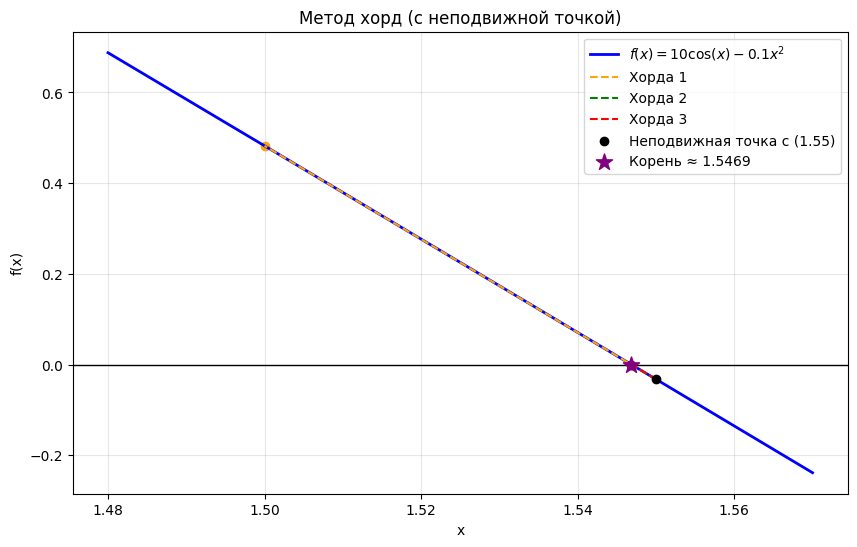

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt


print("ПРАКТИЧЕСКАЯ РАБОТА №4")
print("Метод хорд")
print("Уравнение: 10*cos(x) - 0.1*x^2 = 0")
print("-" * 50)

# Исходная функция
def f(x):
    return 10 * math.cos(x) - 0.1 * x * x

# Границы отрезка [a, b]
a = 1.5
b = 1.55
eps = 0.001
max_iter = 20

print(f"Отрезок: [{a}, {b}]")
print(f"f({a}) = {f(a):.6f}")
print(f"f({b}) = {f(b):.6f}")
print(f"Точность: {eps}")
print()

# Выбираем неподвижную точку c
if abs(f(a)) < abs(f(b)):
    c = a
    x = b
    print(f"Неподвижная точка c = {c}, начальное x0 = {x}")
else:
    c = b
    x = a
    print(f"Неподвижная точка c = {c}, начальное x0 = {x}")
print()

for i in range(max_iter):
    x_old = x
    # Формула метода хорд
    x = (c * f(x_old) - x_old * f(c)) / (f(x_old) - f(c))
    
    print(f"Итерация {i+1}: x{i+1} = {x:.6f}, |x{i+1}-x{i}| = {abs(x - x_old):.6f}")
    
    if abs(x - x_old) < eps:
        print(f"\nТочность достигнута на {i+1}-й итерации!")
        print(f"Корень уравнения: x = {x:.6f}")
        print(f"Округленно: x = {x:.3f}")
        break
else:
    print(f"\nДостигнуто максимальное число итераций ({max_iter})")

def f_val(x):
    return 10 * np.cos(x) - 0.1 * x**2

# Параметры из вашего кода
a, b = 1.5, 1.55
# Логика выбора неподвижной точки как в вашем скрипте
c = a if abs(f_val(a)) < abs(f_val(b)) else b
x_curr = b if c == a else a

# Данные для кривой
x_plot = np.linspace(1.48, 1.57, 400)
y_plot = f_val(x_plot)

plt.figure(figsize=(10, 6))
plt.plot(x_plot, y_plot, label='$f(x) = 10/cos(x) - 0.1x^2$', color='blue', linewidth=2)
plt.axhline(0, color='black', linewidth=1)

# Отрисовка хорд
colors = ['orange', 'green', 'red']
for i in range(3): # Рисуем первые 3 шага
    f_c = f_val(c)
    f_x = f_val(x_curr)
    
    # Координаты хорды
    plt.plot([c, x_curr], [f_c, f_x], '--', color=colors[i], label=f'Хорда {i+1}')
    plt.scatter([x_curr], [f_x], color=colors[i])
    
    # Вычисление следующего x (пересечение хорды с осью OX)
    x_next = (c * f_x - x_curr * f_c) / (f_x - f_c)
    x_curr = x_next

# Точки c и финальный корень
plt.scatter([c], [f_val(c)], color='black', zorder=5, label=f'Неподвижная точка c ({c})')
plt.scatter([x_curr], [0], color='purple', marker='*', s=150, zorder=6, label=f'Корень ≈ {x_curr:.4f}')

plt.title('Метод хорд (с неподвижной точкой)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()